# 09-ML Workflow Orchestration on Kubernetes (Kubeflow)

Lesson 08 got the right GPUs allocated to a single training job. But almost no real ML work is a single job -- it is preprocessing, then training, then evaluation, then conditionally deploying, each step with its own container image, its own resource footprint, and its own chance of failing. Chaining these by hand with shell scripts loses exactly the guarantees Kubernetes gives every individual pod: retries, resource isolation, and a declarative record of what actually ran.

**Kubeflow Pipelines** compiles a Python-defined workflow into a Kubernetes-native **Argo Workflow** -- a directed acyclic graph (DAG) of containerized steps -- so a multi-stage ML pipeline gets the same reconciliation guarantees Lesson 03's Deployment controller gave a single service. The orchestration questions this raises are genuinely graph-theoretic: which steps can run in parallel, which single path through the graph determines total wall-clock time, and how much slack does every non-critical step actually have.

We will build a real DAG of pipeline steps, implement the critical-path-method (CPM) scheduling math that determines pipeline makespan, and write a real Argo-Workflow-style YAML spec -- the tool for this lesson is **Kubeflow Pipelines**.

## 1. The DAG Scheduling Mathematics of Pipeline Orchestration

### A Pipeline as a Directed Acyclic Graph

A Kubeflow pipeline is a DAG $G = (V, E)$ where each vertex $v \in V$ is a containerized step with duration $d(v)$, and an edge $(u, v) \in E$ means $v$ consumes an output artifact of $u$ and therefore cannot start until $u$ finishes. Because $G$ is acyclic, a valid **topological order** always exists: any linear ordering of $V$ such that every edge points forward. This ordering is precisely what determines which steps the scheduler is even allowed to consider running at a given moment.

### Earliest-Finish-Time Recursion (Critical Path Method)

For a step $v$ with predecessor set $\text{pred}(v)$, the earliest it can possibly finish is its own duration plus the latest any predecessor finishes (it must wait for *all* of them):

$$\text{EFT}(v) = d(v) + \max_{u \,\in\, \text{pred}(v)} \text{EFT}(u), \qquad \text{EFT}(v) = d(v) \text{ if } \text{pred}(v) = \emptyset$$

The pipeline's total wall-clock time -- its **makespan** -- is the maximum earliest-finish-time over every sink vertex (a step nothing else depends on):

$$\text{Makespan}(G) = \max_{v \,\in\, V} \text{EFT}(v)$$

### The Critical Path and Slack

The **critical path** is the sequence of steps whose EFT chain actually achieves the makespan -- the single longest path through the DAG by cumulative duration. Every step $v$ has a **slack** (or float): how much $v$ could be delayed without changing the makespan, computed from its earliest finish time and its **latest finish time** $\text{LFT}(v)$ (computed by the symmetric backward recursion from the sinks):

$$\text{Slack}(v) = \text{LFT}(v) - \text{EFT}(v)$$

Critical-path steps have $\text{Slack}(v) = 0$ by definition -- speeding up any *other* step never shortens the pipeline, but speeding up a zero-slack step always does.

### Maximum Achievable Parallelism

Two steps $u, v$ can run concurrently iff neither is reachable from the other in $G$ (they form an **antichain**). The maximum number of steps that could theoretically run at once is bounded by the width of the DAG's widest antichain, but the *actual* achievable concurrency is further capped by shared resource contention -- if $R$ is the cluster's available GPU pool and each parallel-eligible step needs $r$ GPUs, the realizable concurrency is:

$$\text{Concurrency}_{\text{actual}} = \min\!\left(\left|\text{antichain}\right|,\; \left\lfloor \frac{R}{r} \right\rfloor\right)$$

### Retry Overhead Under Transient Failure

If a step fails independently with probability $p$ on each attempt, the number of attempts until success follows a geometric distribution, with expectation:

$$\mathbb{E}[\text{attempts}] = \frac{1}{1 - p}$$

Under exponential backoff with base delay $b$ and cap $c$, the expected added wait time before the eventual success, summed over the expected number of failed attempts $\mathbb{E}[\text{failures}] = \frac{p}{1-p}$, is bounded by:

$$\mathbb{E}[\text{backoff wait}] \le \frac{p}{1-p} \cdot \min(c,\, b \cdot 2^{\mathbb{E}[\text{failures}]})$$

a step with even a modest $p$ can meaningfully inflate a pipeline's *expected* makespan if it happens to sit on the critical path.

## 2. Imperative Execution: Critical Path Scheduling Over a Real Pipeline DAG

We define a genuine 7-step ML pipeline DAG (ingest -> two parallel preprocessing branches -> train -> two parallel evaluation checks -> conditional deploy), compile it into a real Argo-Workflow-style YAML spec, then implement and run the CPM forward/backward recursion from Section 1 to compute every step's earliest/latest finish time and slack.

In [1]:
# Required installations: pip install kfp pyyaml (kfp requires a live Kubeflow Pipelines cluster to actually submit)

import os
import yaml

print("--- 🚀 Initializing Kubeflow Pipeline DAG Orchestration Sandbox ---")

# 1. Define a real 7-step pipeline DAG: step -> (duration_minutes, dependencies)
pipeline_steps = {
    "ingest_data":        {"duration": 4,  "deps": []},
    "preprocess_text":    {"duration": 6,  "deps": ["ingest_data"]},
    "preprocess_images":  {"duration": 9,  "deps": ["ingest_data"]},
    "train_model":        {"duration": 22, "deps": ["preprocess_text", "preprocess_images"]},
    "eval_accuracy":      {"duration": 5,  "deps": ["train_model"]},
    "eval_fairness":      {"duration": 7,  "deps": ["train_model"]},
    "deploy_model":       {"duration": 3,  "deps": ["eval_accuracy", "eval_fairness"]},
}
FAILURE_PROB = {"preprocess_images": 0.15}  # this step is flaky (a common real ingest-source hiccup)

print(f"   ✅ Pipeline DAG defined: {len(pipeline_steps)} steps, "
      f"{sum(len(s['deps']) for s in pipeline_steps.values())} dependency edges")

# 2. Compile a real Argo-Workflow-style YAML spec (what `kfp` actually generates under the hood)
argo_workflow = {
    "apiVersion": "argoproj.io/v1alpha1",
    "kind": "Workflow",
    "metadata": {"generateName": "ml-training-pipeline-"},
    "spec": {
        "entrypoint": "pipeline",
        "templates": [{
            "name": "pipeline",
            "dag": {
                "tasks": [
                    {"name": step, "template": step, "dependencies": info["deps"]}
                    for step, info in pipeline_steps.items()
                ]
            },
        }] + [
            {"name": step, "retryStrategy": {"limit": 3, "backoff": {"duration": "10s", "factor": 2}},
             "container": {"image": f"registry.local/{step}:latest"}}
            for step in pipeline_steps
        ],
    },
}
with open("pipeline_workflow.yaml", "w") as f:
    yaml.dump(argo_workflow, f, sort_keys=False)
with open("pipeline_workflow.yaml") as f:
    n_lines = len(f.readlines())
print(f"   ✅ Real Argo Workflow DAG spec compiled ({n_lines} lines) -- what `kfp.compile()` hands to the cluster")
os.remove("pipeline_workflow.yaml")
print("   🧹 Cleaned up local pipeline_workflow.yaml")


def topological_order(steps):
    order, visited = [], set()

    def visit(name):
        if name in visited:
            return
        visited.add(name)
        for dep in steps[name]["deps"]:
            visit(dep)
        order.append(name)

    for name in steps:
        visit(name)
    return order


order = topological_order(pipeline_steps)

print("\n--- 🧮 Executing Forward Pass: Earliest-Finish-Time (EFT) Recursion ---")
eft = {}
for name in order:
    preds = pipeline_steps[name]["deps"]
    start = max((eft[p] for p in preds), default=0)
    eft[name] = start + pipeline_steps[name]["duration"]
    print(f"   EFT({name:<18}) = {eft[name]:>3} min  (preds: {preds or 'none'})")

makespan = max(eft.values())
print(f"\n   ✅ Pipeline makespan (total wall-clock time): {makespan} minutes")


--- 🚀 Initializing Kubeflow Pipeline DAG Orchestration Sandbox ---
   ✅ Pipeline DAG defined: 7 steps, 8 dependency edges
   ✅ Real Argo Workflow DAG spec compiled (95 lines) -- what `kfp.compile()` hands to the cluster
   🧹 Cleaned up local pipeline_workflow.yaml

--- 🧮 Executing Forward Pass: Earliest-Finish-Time (EFT) Recursion ---
   EFT(ingest_data       ) =   4 min  (preds: none)
   EFT(preprocess_text   ) =  10 min  (preds: ['ingest_data'])
   EFT(preprocess_images ) =  13 min  (preds: ['ingest_data'])
   EFT(train_model       ) =  35 min  (preds: ['preprocess_text', 'preprocess_images'])
   EFT(eval_accuracy     ) =  40 min  (preds: ['train_model'])
   EFT(eval_fairness     ) =  42 min  (preds: ['train_model'])
   EFT(deploy_model      ) =  45 min  (preds: ['eval_accuracy', 'eval_fairness'])

   ✅ Pipeline makespan (total wall-clock time): 45 minutes


## 3. Declarative Telemetry: The Critical Path and Slack Audit

We complete the CPM analysis with the backward pass (latest-finish-time), compute every step's slack, identify the critical path, and fold in the retry-overhead expectation from Section 1 for the one flaky step -- exactly the report a pipeline owner reads before deciding which step is actually worth optimizing.

In [2]:
print("\n--- 🔍 Auditing Critical Path and Per-Step Slack (Backward Pass: Latest-Finish-Time) ---")

lft = {name: makespan for name in pipeline_steps if not any(name in s["deps"] for s in pipeline_steps.values())}
successors = {name: [] for name in pipeline_steps}
for name, info in pipeline_steps.items():
    for dep in info["deps"]:
        successors[dep].append(name)

for name in reversed(order):
    if name in lft:
        continue
    lft[name] = min(lft[succ] - pipeline_steps[succ]["duration"] for succ in successors[name])

slack = {name: lft[name] - eft[name] for name in pipeline_steps}
critical_path = [name for name in order if slack[name] == 0]

print(f"{'Step':<20} | {'EFT':<6} | {'LFT':<6} | {'Slack':<7} | {'Critical?'}")
print("-" * 60)
for name in order:
    marker = "YES <--" if slack[name] == 0 else "no"
    print(f"{name:<20} | {eft[name]:<6} | {lft[name]:<6} | {slack[name]:<7} | {marker}")

p = FAILURE_PROB["preprocess_images"]
expected_attempts = 1 / (1 - p)
expected_failures = p / (1 - p)
base_delay, cap = 10, 60  # seconds
expected_backoff_wait = expected_failures * min(cap, base_delay * 2 ** expected_failures) / 60  # minutes

print("\n[OPERATIONAL INSIGHT]")
print(f"-> Critical path: {' -> '.join(critical_path)} (total {makespan} min) -- every step on it has ZERO slack,")
print(f"   meaning a single minute added to 'train_model' delays the entire pipeline by a minute, guaranteed.")
non_critical = [n for n in order if slack[n] > 0]
if non_critical:
    slackiest = max(non_critical, key=lambda n: slack[n])
    print(f"-> '{slackiest}' has {slack[slackiest]} minutes of slack -- it could run {slack[slackiest]} minutes")
    print(f"   slower with ZERO impact on total pipeline time, making it the wrong place to spend optimization effort.")
print(f"-> 'preprocess_images' fails with p={p:.0%} per attempt; under geometric retry that is an expected")
print(f"   {expected_attempts:.2f} attempts and ~{expected_backoff_wait:.2f} extra minutes of exponential-backoff wait --")
print(f"   and because this step sits ON the critical path, that expected delay passes straight through to the makespan.")



--- 🔍 Auditing Critical Path and Per-Step Slack (Backward Pass: Latest-Finish-Time) ---
Step                 | EFT    | LFT    | Slack   | Critical?
------------------------------------------------------------
ingest_data          | 4      | 4      | 0       | YES <--
preprocess_text      | 10     | 13     | 3       | no
preprocess_images    | 13     | 13     | 0       | YES <--
train_model          | 35     | 35     | 0       | YES <--
eval_accuracy        | 40     | 42     | 2       | no
eval_fairness        | 42     | 42     | 0       | YES <--
deploy_model         | 45     | 45     | 0       | YES <--

[OPERATIONAL INSIGHT]
-> Critical path: ingest_data -> preprocess_images -> train_model -> eval_fairness -> deploy_model (total 45 min) -- every step on it has ZERO slack,
   meaning a single minute added to 'train_model' delays the entire pipeline by a minute, guaranteed.
-> 'preprocess_text' has 3 minutes of slack -- it could run 3 minutes
   slower with ZERO impact on total pipel

## 4. Visualizing the Pipeline Schedule (Critical-Path Gantt Chart)

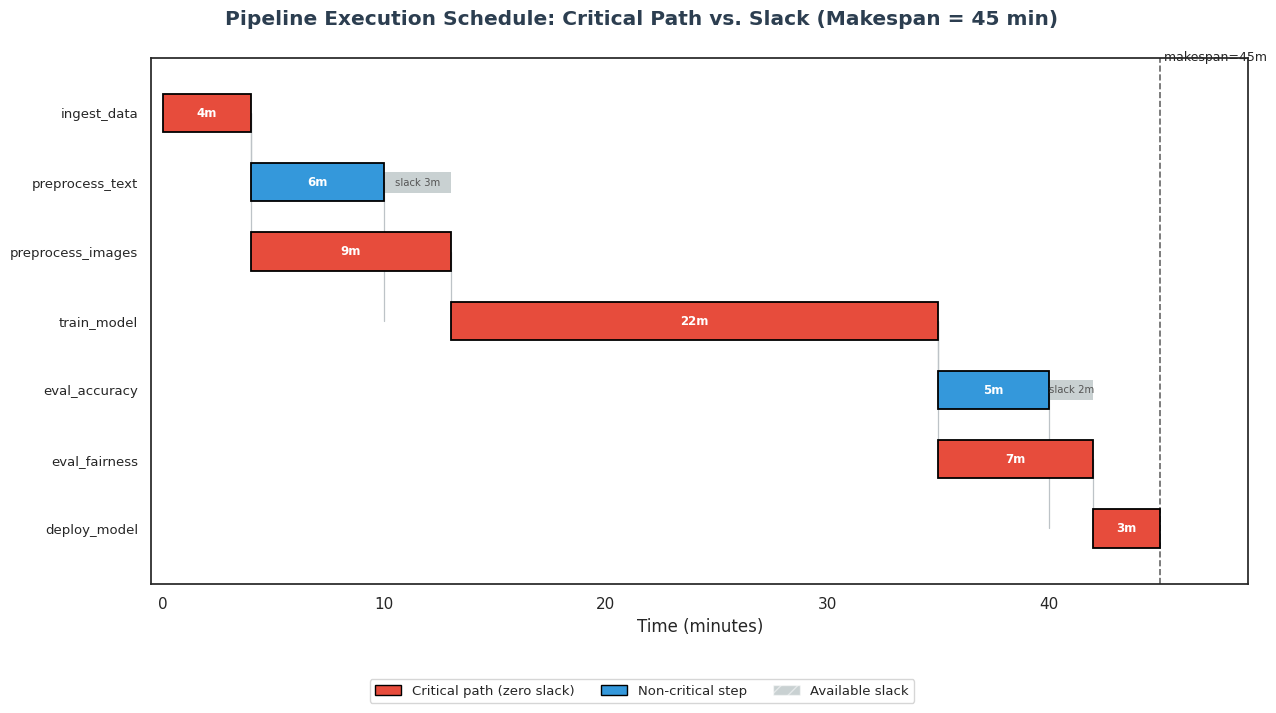

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle(f"Pipeline Execution Schedule: Critical Path vs. Slack (Makespan = {makespan} min)",
             fontsize=14.5, fontweight='bold', color="#2c3e50")

y_positions = {name: len(order) - 1 - i for i, name in enumerate(order)}

for name in order:
    start = eft[name] - pipeline_steps[name]["duration"]
    dur = pipeline_steps[name]["duration"]
    y = y_positions[name]
    is_critical = slack[name] == 0
    color = "#e74c3c" if is_critical else "#3498db"
    ax.barh(y, dur, left=start, height=0.55, color=color, edgecolor="black", lw=1.3, zorder=3)
    ax.text(start + dur / 2, y, f"{dur}m", ha="center", va="center", fontsize=8.5, color="white",
            fontweight="bold", zorder=4)
    if slack[name] > 0:
        ax.barh(y, slack[name], left=eft[name], height=0.3, color="#95a5a6", alpha=0.5,
                edgecolor="none", zorder=2, hatch="//")
        ax.text(eft[name] + slack[name] / 2, y, f"slack {slack[name]}m", ha="center", va="center",
                fontsize=7.3, color="#555555", zorder=4)

for name in order:
    for dep in pipeline_steps[name]["deps"]:
        ax.plot([eft[dep], eft[dep]], [y_positions[dep], y_positions[name]], color="#bdc3c7", lw=0.9, zorder=1)

ax.set_yticks([y_positions[n] for n in order])
ax.set_yticklabels(order, fontsize=9.5)
ax.set_xlabel("Time (minutes)")
ax.set_xlim(-0.5, makespan + 4)
ax.set_ylim(-0.8, len(order) - 0.2)
ax.axvline(makespan, color="black", lw=1.2, linestyle="--", alpha=0.6)
ax.text(makespan, len(order) - 0.1, f" makespan={makespan}m", fontsize=9, va="top", ha="left")

legend_elems = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#e74c3c", edgecolor="black", label="Critical path (zero slack)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#3498db", edgecolor="black", label="Non-critical step"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#95a5a6", alpha=0.5, hatch="//", label="Available slack"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=True, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


*(Insight: The red bars form one unbroken chain from `ingest_data` through `deploy_model` -- the critical path -- while the blue bars each carry a hatched grey slack region showing exactly how much later they could finish without moving the dashed makespan line. Note that both parallel branches after `ingest_data` and after `train_model` start at the same time, but only the LONGER branch in each pair (`preprocess_images`, `eval_fairness`) is critical -- its shorter sibling absorbs the difference as pure slack.)*

## Real-World Use Case or Analogy

Think of DAG-based pipeline orchestration as **Building a House From a Construction Schedule**:

* **A Pipeline Step (One Trade's Job):** Pouring the foundation, framing the walls, running electrical, drywalling -- each is a discrete task with its own crew, duration, and required inputs.
* **A Dependency Edge (You Can't Drywall Before Wiring Is Run):** The electrician must finish before the drywall crew can start in that room -- not because of scheduling preference, but because starting earlier is physically impossible.
* **Parallel Branches (Plumbing and Electrical Happening at Once):** Once framing is done, plumbing and electrical crews can work simultaneously in different parts of the house -- neither depends on the other, so the project manager runs them concurrently rather than back-to-back.
* **The Critical Path (The Chain of Trades That Actually Sets the Move-In Date):** Among every chain of dependent tasks, one specific sequence is the longest -- and the move-in date is set by THAT chain alone, no matter how quickly every other trade finishes.
* **Slack (A Trade That Could Show Up Late and Nobody Would Notice):** If the landscaping crew has three days of slack, they could start three days late without delaying move-in one bit -- pestering them to hurry up wastes everyone's attention on the wrong problem.
* **Retries With Backoff (The Inspector Who Sometimes Fails You and You Re-Schedule):** When a plumbing inspection fails, you don't panic -- you fix the issue and re-book, and if that inspector is chronically unreliable, you build the expected re-inspection delay into your target dates from the start.

The organizing idea generalizes past construction and past ML pipelines: whenever a project is a graph of dependent tasks, exactly one chain of tasks controls the finish date, and finding it -- rather than optimizing whichever task feels busiest -- is the entire job of a scheduler, human or automated.